# 📘 Notebook 2: Correlation, Covariance & Hypothesis Testing
This notebook provides a **deep and intuitive explanation** of:
- Correlation & Covariance
- P-value and hypothesis testing
- ANOVA (Analysis of Variance)
- Chi-Square Test

We will use **visualizations, examples, and counter-examples** to fully grasp these concepts.

## 🔹 Part 1 – Correlation & Covariance

**Correlation** measures the strength and direction of a linear relationship between two variables.

- Ranges between **-1 and 1**
- **+1**: perfect positive relationship
- **-1**: perfect negative relationship
- **0**: no linear relationship

⚠️ **Important:** Correlation does not imply causation.

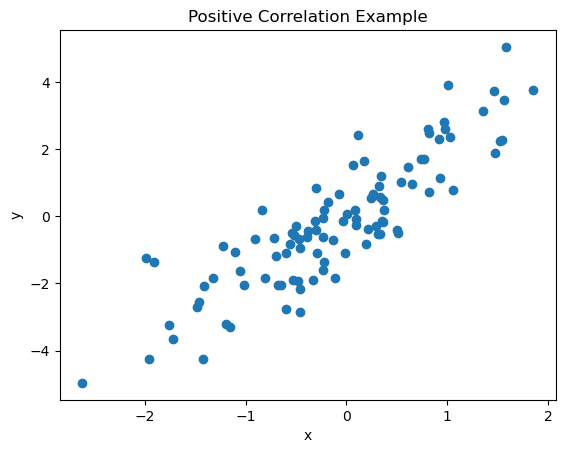

np.float64(0.8724042787137847)

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Simulate correlated data
np.random.seed(42)
x = np.random.normal(0, 1, 100)
y = 2*x + np.random.normal(0, 1, 100)  # correlated with x

plt.scatter(x, y)
plt.title("Positive Correlation Example")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Correlation coefficient
np.corrcoef(x, y)[0,1]


**Covariance** indicates how two variables change together.

- Positive covariance: when one increases, the other tends to increase.
- Negative covariance: when one increases, the other tends to decrease.

Formula:
$$\text{Cov}(X,Y) = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{n-1}$$

## 🔹 Part 2 – P-Value

The **p-value** is the probability of obtaining results at least as extreme as the observed results, assuming that the null hypothesis is true.

**Example:** Toss a coin 10 times. If the coin is fair (null hypothesis), we expect about 5 heads.
If we observe 9 heads, is that likely due to chance? The p-value will tell us.

In [2]:

import scipy.stats as stats

# Example: Coin toss, probability of 9 or more heads in 10 tosses of a fair coin
p_value = sum(stats.binom.pmf(range(9, 11), n=10, p=0.5))
p_value


np.float64(0.010742187500000002)

👉 If the p-value < 0.05, we reject the null hypothesis (the coin may not be fair).

## 🔹 Part 3 – ANOVA (Analysis of Variance)

ANOVA is used to compare the means of **3 or more groups**.

**Example:** Compare exam scores of students taught with 3 different methods.

In [3]:
np.random.normal(70, 10, 30)

array([ 73.5778736 ,  75.60784526,  80.83051243,  80.53802052,
        56.22330632,  60.6217496 ,  75.15035267,  75.13785951,
        75.15047686, 108.52731491,  75.70890511,  81.3556564 ,
        79.54001763,  76.51391251,  66.84730755,  77.5896922 ,
        62.27174785,  67.63181393,  65.14636452,  70.81874139,
        93.14658567,  51.32734807,  76.8626019 ,  53.87284129,
        65.28068134,  80.88950597,  70.64280019,  59.22255222,
        62.84696291,  76.79597749])

In [4]:

import numpy as np
from scipy.stats import f_oneway

# Simulated exam scores
np.random.seed(42)
method1 = np.random.normal(70, 10, 30)
method2 = np.random.normal(75, 10, 30)
method3 = np.random.normal(80, 10, 30)

f_stat, p_val = f_oneway(method1, method2, method3)
f_stat, p_val


(np.float64(12.20952551797281), np.float64(2.120074814050707e-05))

👉 Interpretation:
- Null hypothesis: All group means are equal.
- If p-value < 0.05 → At least one group is significantly different.

## 🔹 Part 4 – Chi-Square Test

The **Chi-Square Test** checks the independence between two categorical variables.

**Example:** Titanic dataset → Is survival independent of sex?

In [6]:

import pandas as pd
from scipy.stats import chi2_contingency

# Example contingency table
data = pd.DataFrame({
    'Survived': [200, 100],  # yes, no
    'Not Survived': [80, 300]  # male, female
}, index=['Female','Male'])

chi2, p, dof, expected = chi2_contingency(data)
chi2, p


(np.float64(142.13297368421053), np.float64(9.095068480309298e-33))

👉 If p < 0.05, we reject the null hypothesis that the variables are independent.

## 🔹 Part 5 – Summary & ML Context
- **Correlation**: Useful for checking linear relationships between features.
- **Covariance**: Tells direction of relationship, but not strength.
- **P-value**: Helps test hypotheses. Low p-value (<0.05) means strong evidence against null.
- **ANOVA**: Compares multiple group means, often used in feature selection.
- **Chi-Square**: Useful for categorical features in classification tasks.

✅ These tests are essential in **EDA** and **feature selection** before training ML/DL models.